In [1]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("data_A.csv")

print("Shape Dataset:")
print(df.shape)

df.head()

Shape Dataset:
(25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


# Business Understanding
Problem Statement

Institusi keuangan ingin mengklasifikasikan kualitas kredit nasabah menjadi Good, Standard, dan Poor berdasarkan informasi finansial pelanggan.

Objective

Membangun model machine learning yang mampu memprediksi Credit Score pelanggan secara akurat.

# Data understanding

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

# Dataset Overview

Dataset yang digunakan pada proyek ini adalah **Credit Score Classification Dataset** yang berisi informasi finansial dan perilaku kredit pelanggan. Tujuan utama dari dataset ini adalah untuk memprediksi kategori **Credit Score** pelanggan ke dalam tiga kelas, yaitu **Good**, **Standard**, dan **Poor**.

## Struktur Dataset

Dataset terdiri dari **25.000 observasi (baris)** dan **29 atribut (kolom)** yang mencakup informasi identitas pelanggan, kondisi keuangan, riwayat kredit, perilaku pembayaran, serta label credit score.

### Ringkasan Dataset

- Jumlah Baris: **25.000**
- Jumlah Kolom: **29**
- Memory Usage: **5.5 MB**
- Target Variable: **Credit_Score**

### Tipe Data

| Tipe Data | Jumlah Kolom |
|------------|-------------|
| Object | 20 |
| Integer | 5 |
| Float | 4 |

Dataset mengandung kombinasi antara fitur numerik dan kategorikal. Beberapa fitur numerik masih tersimpan dalam format **object** sehingga memerlukan proses pembersihan data (data cleaning) sebelum digunakan dalam proses pemodelan machine learning.

## Identifikasi Awal Dataset

Berdasarkan hasil inspeksi awal, ditemukan beberapa karakteristik dataset yang perlu diperhatikan:

1. Terdapat beberapa fitur yang memiliki missing values, seperti:
   - Name
   - Monthly_Inhand_Salary
   - Type_of_Loan
   - Num_of_Delayed_Payment
   - Num_Credit_Inquiries
   - Credit_History_Age
   - Amount_invested_monthly
   - Monthly_Balance

2. Beberapa fitur numerik masih tersimpan dalam format object, seperti:
   - Age
   - Annual_Income
   - Num_of_Loan
   - Outstanding_Debt
   - Monthly_Balance

3. Terdapat beberapa fitur identitas yang tidak memiliki nilai prediktif terhadap Credit Score dan berpotensi menyebabkan data leakage, seperti:
   - ID
   - Customer_ID
   - Name
   - SSN

4. Dataset merupakan kasus **Multiclass Classification**, dengan target berupa kategori:
   - Good
   - Standard
   - Poor

Berdasarkan karakteristik tersebut, tahap berikutnya akan dilakukan **Exploratory Data Analysis (EDA)** dan **Data Preprocessing** untuk menghasilkan dataset yang siap digunakan dalam proses pelatihan model machine learning.

# EDA

In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: Index(['Unnamed: 0', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date',
       'Num_Credit_Inquiries', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month'],
      dtype='object')
Categorical Features: Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


In [5]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Monthly_Inhand_Salary      3583
Type_of_Loan               2828
Name                       2560
Credit_History_Age         2249
Num_of_Delayed_Payment     1733
Amount_invested_monthly    1164
Num_Credit_Inquiries        506
Monthly_Balance             289
dtype: int64

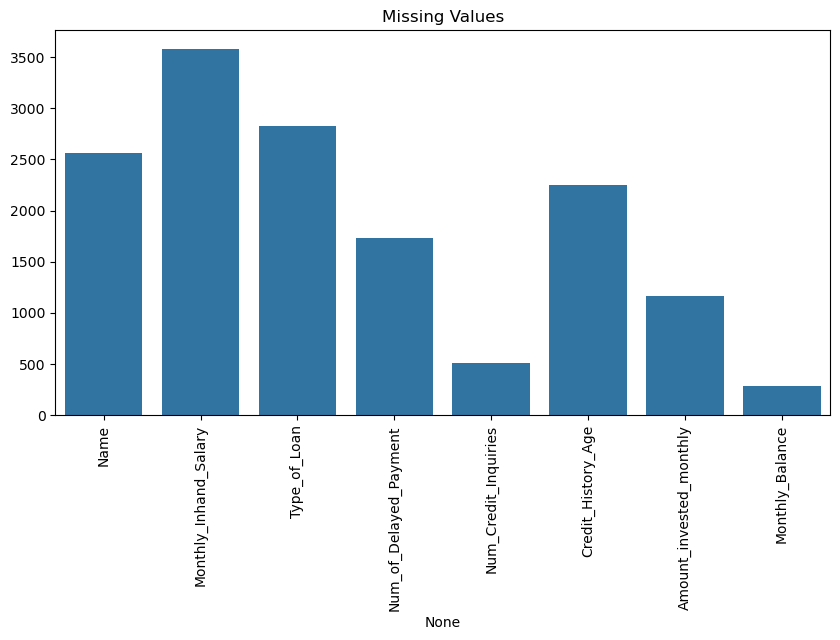

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing[missing>0].index,
    y=missing[missing>0].values
)

plt.xticks(rotation=90)
plt.title("Missing Values")
plt.show()

### Insight

Berdasarkan visualisasi missing values, ditemukan beberapa fitur yang memiliki nilai kosong, terutama pada kolom Name, Monthly_Inhand_Salary, Type_of_Loan, Credit_History_Age, dan Amount_invested_monthly. Kondisi ini menunjukkan bahwa proses data preprocessing diperlukan sebelum model machine learning dibangun. Missing values pada fitur numerik akan ditangani menggunakan imputasi median, sedangkan fitur kategorikal akan menggunakan modus (most frequent value).

In [7]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


### Insight

Pemeriksaan data duplikat dilakukan untuk memastikan bahwa setiap observasi mewakili satu kondisi pelanggan yang unik. Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki duplikasi yang signifikan sehingga tidak diperlukan proses penghapusan data duplikat dalam jumlah besar.

# inconsistent values

In [8]:
for col in df.select_dtypes(include='object').columns:
    
    suspicious = df[
        df[col].astype(str).str.contains(
            r'_|NM|nan',
            case=False,
            na=False
        )
    ][col]

    if len(suspicious) > 0:

        print("="*80)
        print(f"Column: {col}")
        print(f"Suspicious Records: {len(suspicious)}")

        print(
            suspicious
            .drop_duplicates()
            .head(20)
            .tolist()
        )

Column: Customer_ID
Suspicious Records: 25000
['CUS_0x936d', 'CUS_0x9a29', 'CUS_0x12a9', 'CUS_0x3bad', 'CUS_0xa3e1', 'CUS_0x5e18', 'CUS_0x2e1d', 'CUS_0xb4c5', 'CUS_0xb4fd', 'CUS_0x6b44', 'CUS_0x8031', 'CUS_0x6f0f', 'CUS_0x715f', 'CUS_0xb713', 'CUS_0x1cc3', 'CUS_0x2e53', 'CUS_0x29ac', 'CUS_0xbd2e', 'CUS_0xc163', 'CUS_0x2af3']
Column: Name
Suspicious Records: 2858
['Nanette Byrness', nan, 'Laura Noonanw', 'Nick Brownm', 'Lucianan', 'Krishnanh', 'Baertleinm', 'Xiaowenm', 'Noonang', 'Krishnank', 'A. Ananthalakshmiq', 'Emily Stephensonm', 'Cohenm', 'arani Krishnanx', 'Klaymanm', 'Denan', 'Anna Yukhananovt', 'Daniel Flynnm', 'Krishnanp', 'Noonanm']
Column: Age
Suspicious Records: 1220
['39_', '35_', '36_', '44_', '43_', '52_', '31_', '22_', '38_', '41_', '33_', '40_', '50_', '29_', '30_', '20_', '53_', '27_', '21_', '32_']
Column: Occupation
Suspicious Records: 3345
['_______', 'Media_Manager']
Column: Annual_Income
Suspicious Records: 1756
['19267.27_', '40554.44_', '62901.08_', '44964.22_'

In [9]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].sample(10))

ID
17211    0x2514a
11373     0xe439
10325     0xa555
16247    0x24187
16024    0x1f092
1449     0x1774f
4931     0x179d1
16180    0x119b7
10060    0x2498d
5297      0xf9e1
Name: ID, dtype: object
Customer_ID
11212    CUS_0xb82d
867      CUS_0x745b
23013    CUS_0x8cd3
17752    CUS_0xa987
3627     CUS_0x753d
109      CUS_0x3dc3
14757    CUS_0x776d
16504    CUS_0x7e2f
1662     CUS_0x4f83
22965    CUS_0x2b00
Name: Customer_ID, dtype: object
Month
11477        July
4203        April
8913      January
21518      August
15194    February
4653      January
17009      August
24737        June
1700      January
5128         July
Name: Month, dtype: object
Name
16701    Svea Herbst-Baylissa
4447                 LaCaprad
3930          Lisa Twaronitej
18793                   Sarax
9982         Jonathan Spicerb
23699       Alexei Oreskovicl
17546                 Andreax
711                    Lopezh
8511                    Daveq
21911        "Eileen OGrady"w
Name: Name, dtype: object
Age
13977    3

In [10]:
summary = []

for col in df.columns:

    summary.append({
        "Column": col,
        "Data Type": df[col].dtype,
        "Missing Values": df[col].isna().sum(),
        "Unique Values": df[col].nunique()
    })

eda_summary = pd.DataFrame(summary)

eda_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Data Type,Missing Values,Unique Values
9,Monthly_Inhand_Salary,float64,3583,10903
14,Type_of_Loan,object,2828,5740
4,Name,object,2560,9027
22,Credit_History_Age,object,2249,404
16,Num_of_Delayed_Payment,object,1733,240
25,Amount_invested_monthly,object,1164,22759
18,Num_Credit_Inquiries,float64,506,399
27,Monthly_Balance,object,289,24708
26,Payment_Behaviour,object,0,7
24,Total_EMI_per_month,float64,0,10979


## EDA numerik

In [11]:
df[numerical_cols].describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.000000,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,24494.000000,25000.000000,25000.000000
mean,12499.500000,4215.671131,17.235440,22.143080,71.214040,21.192000,28.149669,32.295884,1406.139718
std,7217.022701,3187.623134,118.307474,127.701822,463.669065,14.887254,194.452923,5.090592,8242.321932
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.172942,0.000000
25%,6249.750000,1634.720833,4.000000,4.000000,8.000000,10.000000,3.000000,28.104589,30.750519
50%,12499.500000,3111.437500,6.000000,5.000000,13.000000,18.000000,6.000000,32.288376,70.523826
75%,18749.250000,5986.647500,7.000000,7.000000,20.000000,28.000000,9.000000,36.480066,163.598381
max,24999.000000,15167.180000,1798.000000,1499.000000,5775.000000,67.000000,2597.000000,48.489852,82236.000000


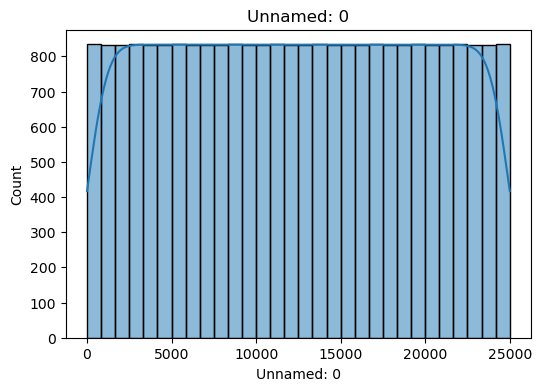

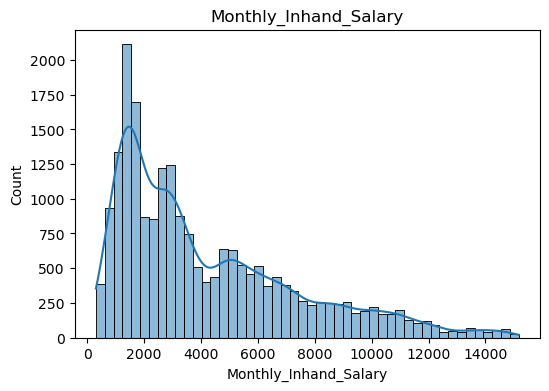

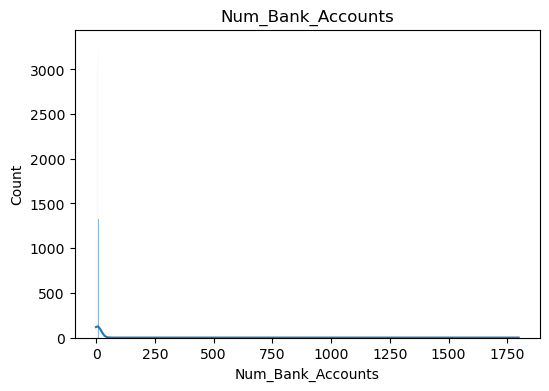

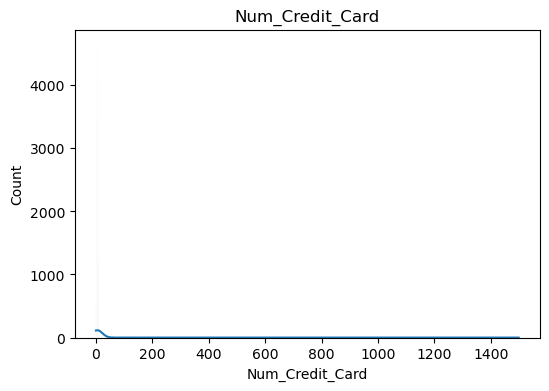

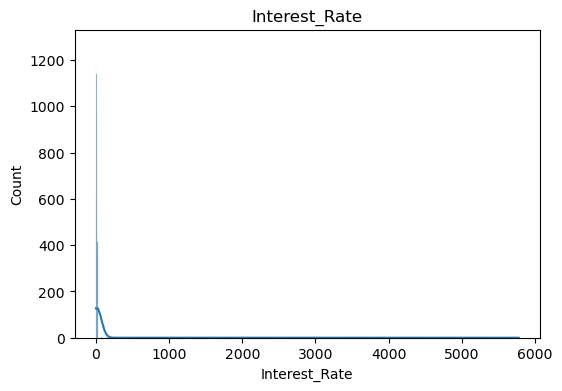

In [12]:
for col in numerical_cols[:5]:
    
    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

### Insight

Distribusi fitur numerik menunjukkan bahwa sebagian besar variabel memiliki sebaran yang tidak sepenuhnya normal dan beberapa fitur menunjukkan skewness yang cukup tinggi. Kondisi ini umum ditemukan pada data finansial karena adanya perbedaan karakteristik pelanggan. Oleh karena itu, proses scaling dan evaluasi beberapa algoritma machine learning diperlukan untuk mendapatkan model yang optimal.

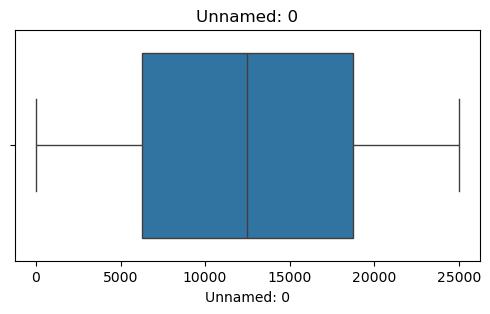

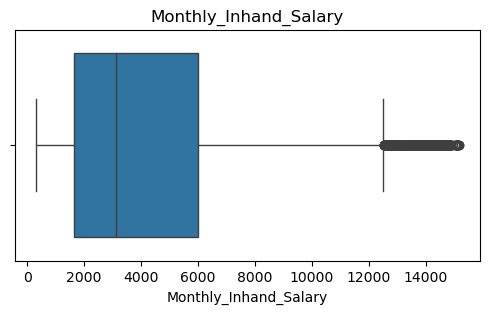

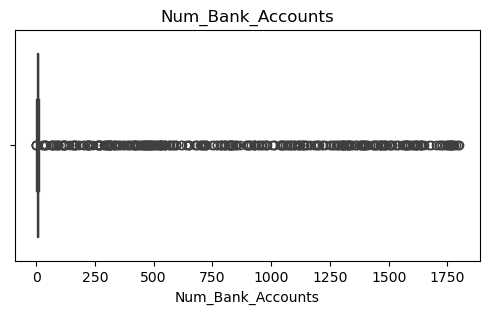

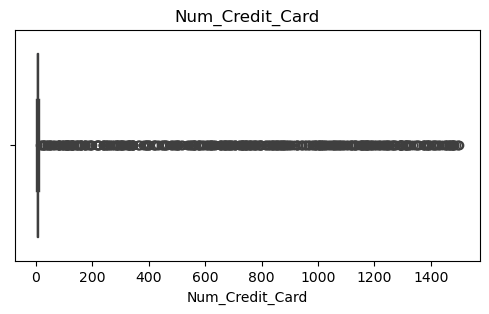

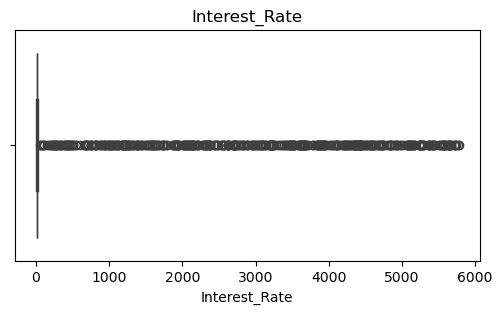

In [13]:
for col in numerical_cols[:5]:
    
    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

### Insight

Visualisasi boxplot menunjukkan keberadaan sejumlah outlier pada beberapa fitur finansial seperti Annual Income, Outstanding Debt, dan Monthly Balance. Outlier tersebut dapat merepresentasikan pelanggan dengan kondisi finansial ekstrem sehingga tidak langsung dihapus. Namun demikian, pengaruh outlier akan dipertimbangkan pada tahap preprocessing dan pemilihan model.

# EDA kategorikal

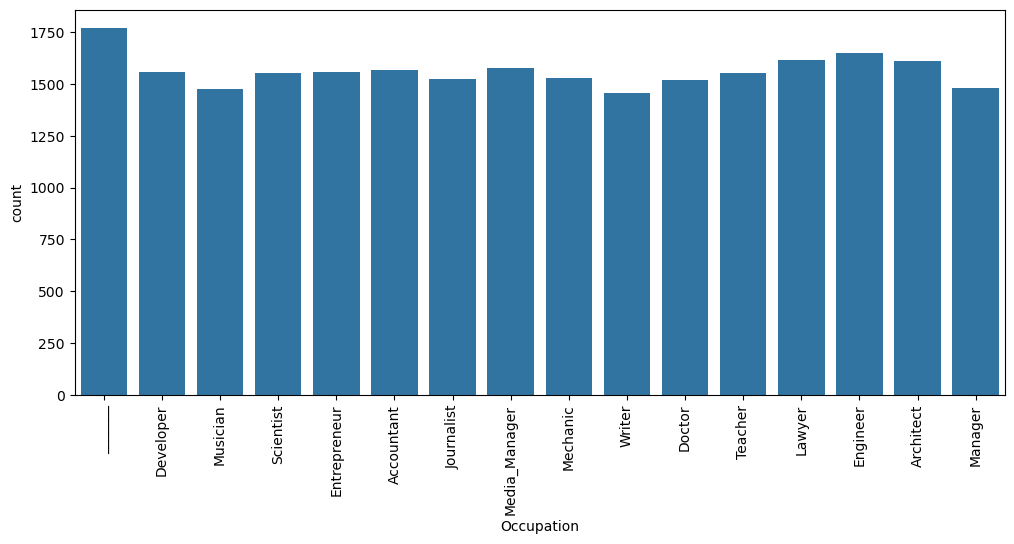

In [14]:
#Distribusi occupation
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Occupation"
)

plt.xticks(rotation=90)

plt.show()

<Axes: xlabel='Credit_Mix', ylabel='count'>

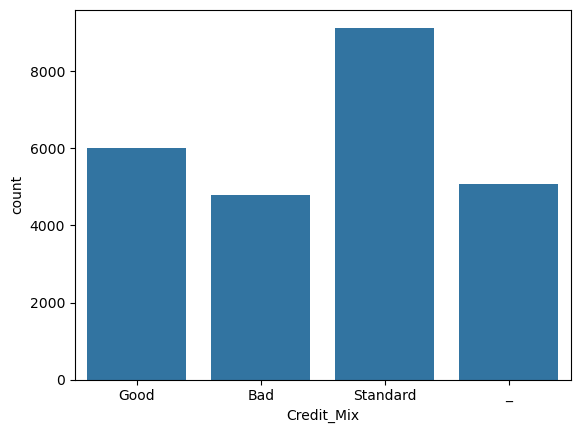

In [15]:
#distribusi credit mix
sns.countplot(
    data=df,
    x="Credit_Mix"
)

# EDA terhadap target

<Axes: xlabel='Credit_Score', ylabel='count'>

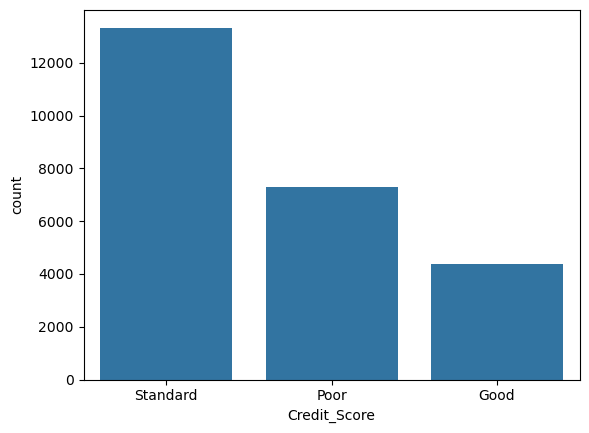

In [16]:
#credit score distribution
sns.countplot(
    data=df,
    x="Credit_Score"
)

### Insight

Distribusi target menunjukkan bahwa kelas **Standard** merupakan kelas mayoritas dengan jumlah data terbanyak, diikuti oleh kelas **Poor** dan **Good**. Kondisi ini menunjukkan adanya ketidakseimbangan kelas (class imbalance) ringan, namun distribusi masih cukup representatif untuk membangun model klasifikasi multiclass. Oleh karena itu, metrik evaluasi seperti Precision, Recall, dan F1-Score akan digunakan selain Accuracy untuk memastikan performa model pada seluruh kelas.

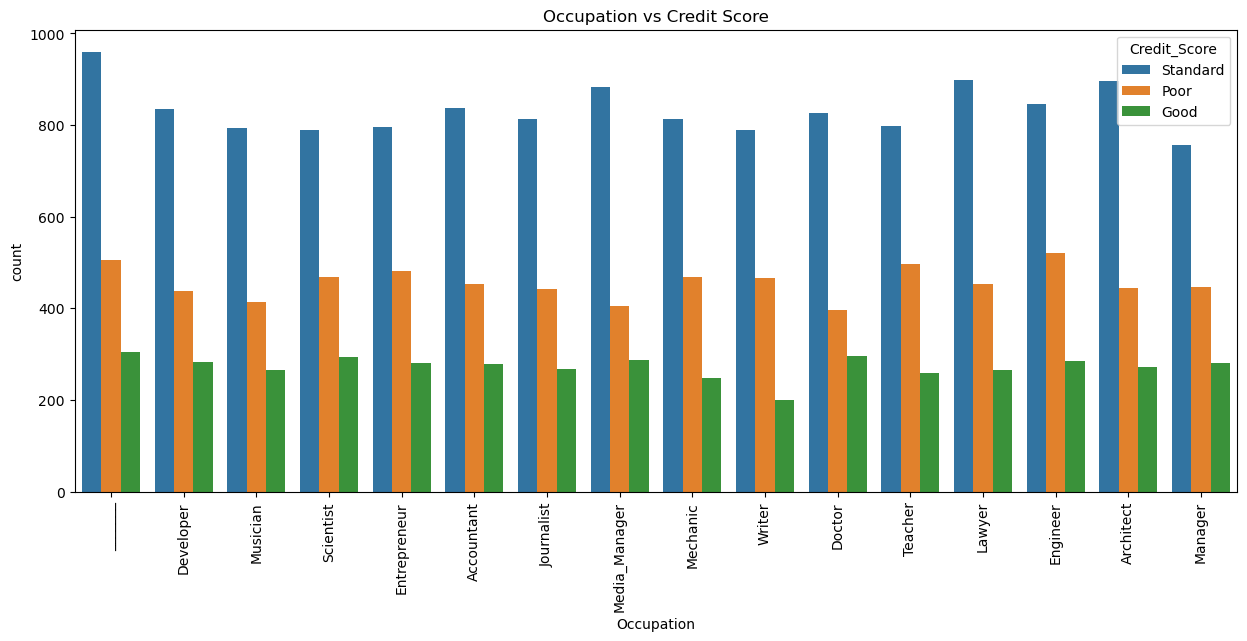

In [17]:
# occupation vs credit score
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x='Occupation',
    hue='Credit_Score'
)

plt.xticks(rotation=90)

plt.title('Occupation vs Credit Score')

plt.show()

### Insight

Distribusi Credit Score bervariasi pada setiap jenis pekerjaan. Beberapa pekerjaan menunjukkan proporsi pelanggan dengan Credit Score Good yang lebih tinggi dibandingkan pekerjaan lainnya. Hal ini mengindikasikan bahwa Occupation berpotensi menjadi salah satu fitur yang berkontribusi dalam proses prediksi Credit Score.

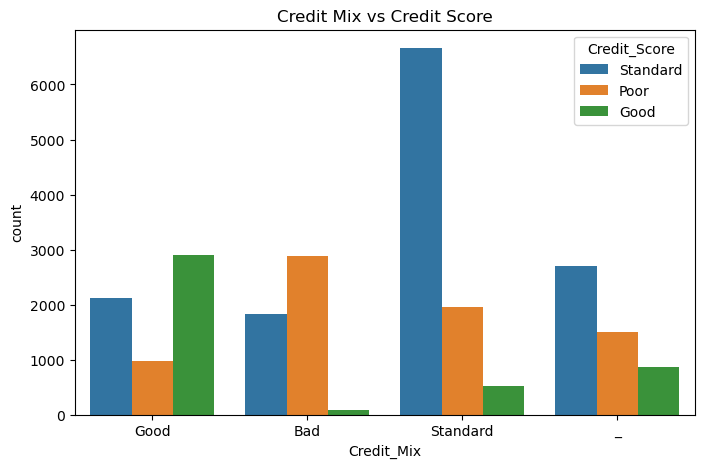

In [18]:
# credit mix vs credit score
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Credit_Mix',
    hue='Credit_Score'
)

plt.title('Credit Mix vs Credit Score')

plt.show()

### Insight

Jenis Credit Mix menunjukkan hubungan yang cukup jelas terhadap kualitas kredit pelanggan. Pelanggan dengan kombinasi kredit yang lebih sehat cenderung memiliki proporsi Credit Score Good yang lebih tinggi. Temuan ini menunjukkan bahwa Credit Mix merupakan salah satu indikator penting dalam penilaian risiko kredit.

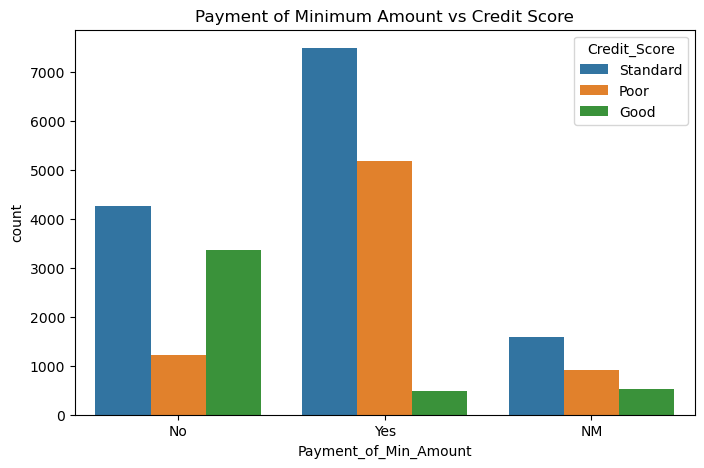

In [19]:
# Payment of Minimum Amount vs Credit Score
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Payment_of_Min_Amount',
    hue='Credit_Score'
)

plt.title('Payment of Minimum Amount vs Credit Score')

plt.show()

### Insight

Pelanggan yang secara konsisten melakukan pembayaran minimum memiliki distribusi Credit Score yang berbeda dibandingkan pelanggan yang tidak melakukan pembayaran minimum. Variabel ini dapat menjadi indikator kemampuan pelanggan dalam memenuhi kewajiban finansialnya sehingga relevan digunakan dalam proses pemodelan.

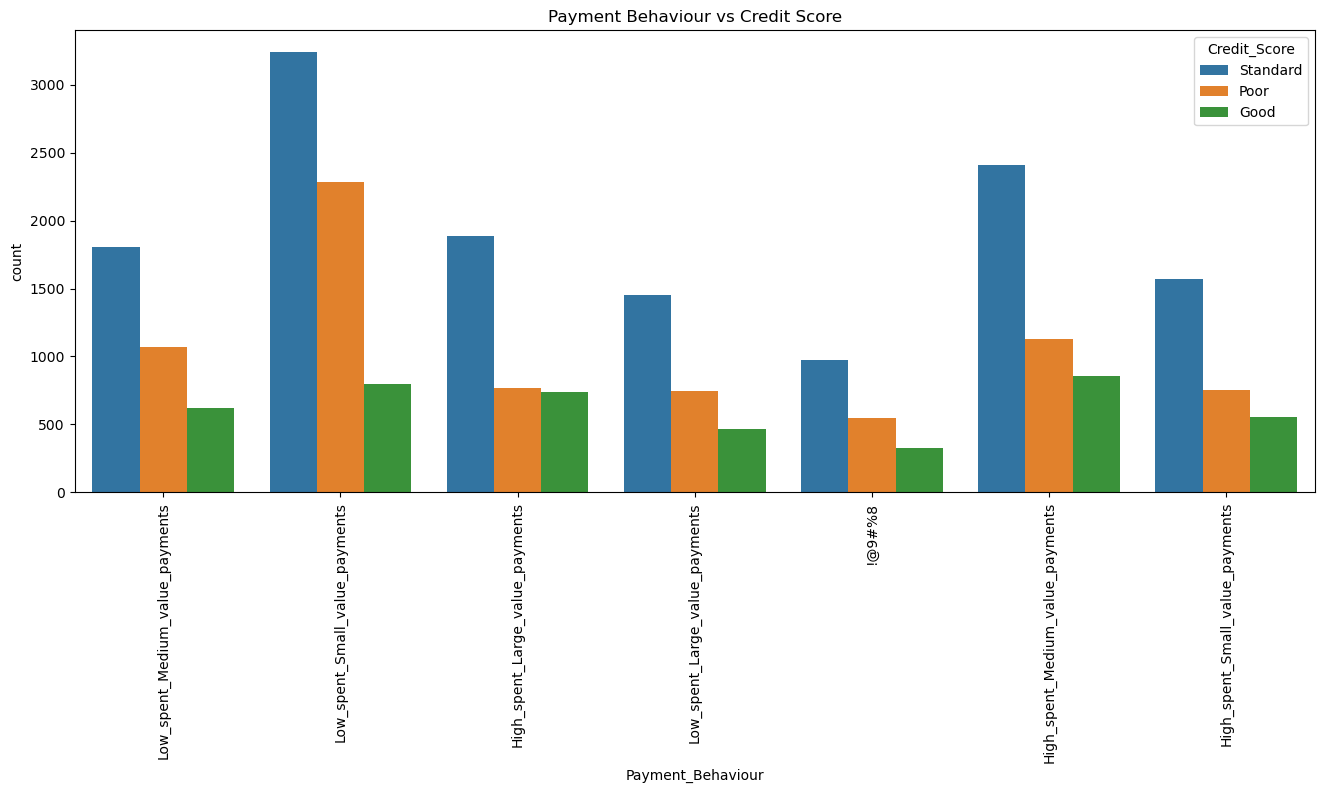

In [20]:
#Payment Behaviour vs Credit Score
plt.figure(figsize=(16,6))

sns.countplot(
    data=df,
    x='Payment_Behaviour',
    hue='Credit_Score'
)

plt.xticks(rotation=90)

plt.title('Payment Behaviour vs Credit Score')

plt.show()

### Insight

Payment Behaviour menunjukkan hubungan yang cukup kuat dengan kualitas kredit pelanggan. Pelanggan yang memiliki pola pembayaran lebih disiplin cenderung berada pada kategori Credit Score yang lebih baik dibandingkan pelanggan dengan perilaku pembayaran yang kurang baik.

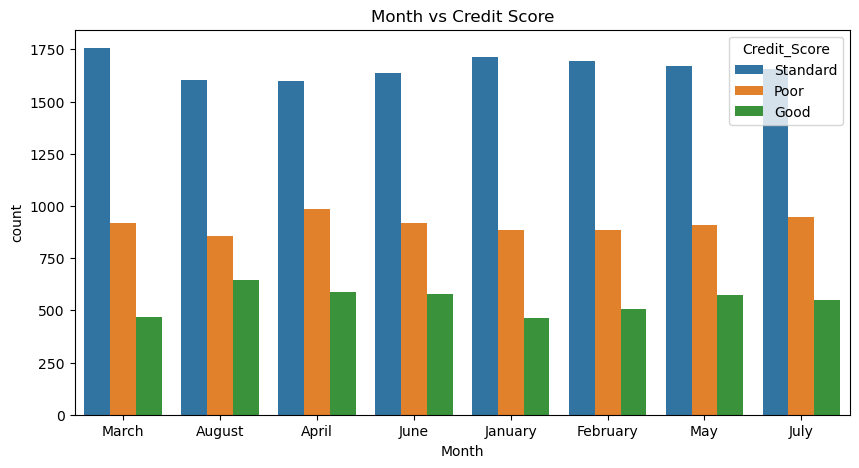

In [21]:
# month vs credit score
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Month',
    hue='Credit_Score'
)

plt.title('Month vs Credit Score')

plt.show()

### Insight

Distribusi Credit Score pada setiap bulan relatif stabil dan tidak menunjukkan pola musiman yang sangat kuat. Hal ini mengindikasikan bahwa variasi kualitas kredit pelanggan lebih dipengaruhi oleh kondisi finansial dibandingkan faktor waktu.

# EDA Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA), ditemukan beberapa permasalahan kualitas data seperti missing values, format data yang tidak konsisten, serta keberadaan outlier pada beberapa fitur finansial. Selain itu, beberapa fitur menunjukkan hubungan yang cukup kuat terhadap Credit Score, antara lain Credit Mix, Payment Behaviour, Payment of Minimum Amount, Occupation, serta beberapa variabel finansial yang akan dibersihkan lebih lanjut pada tahap preprocessing.

Distribusi target menunjukkan bahwa kelas Standard merupakan kelas mayoritas, diikuti oleh Poor dan Good. Meskipun terdapat ketidakseimbangan kelas, distribusinya masih cukup representatif untuk membangun model klasifikasi multiclass.

Berdasarkan temuan tersebut, tahap selanjutnya akan difokuskan pada data preprocessing yang mencakup data cleaning, penanganan missing values, feature engineering, encoding, scaling, dan feature selection sebelum dilakukan pembangunan model machine learning.

# feature selection
Feature Selection dilakukan untuk memilih fitur yang relevan terhadap proses prediksi Credit Score dan menghilangkan fitur yang tidak memberikan informasi prediktif atau berpotensi menyebabkan data leakage.

In [22]:
# Columns to be removed

drop_cols = [
    'Unnamed: 0',
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

df = df.drop(columns=drop_cols)

print("Remaining Features :", df.shape[1])
df.head()

Remaining Features : 24


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,March,8466,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,April,44,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,June,29,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,January,45,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [23]:
print(df.columns.tolist())

['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


### Insight

Sebanyak lima fitur dihapus dari dataset karena hanya berfungsi sebagai identifier dan tidak memiliki hubungan langsung dengan kualitas kredit pelanggan. Penghapusan fitur tersebut bertujuan untuk mengurangi noise dan mencegah model mempelajari informasi yang tidak relevan.

In [24]:
target = 'Credit_Score'

features = [
    col for col in df.columns
    if col != target
]

print("Number of Features :", len(features))
print("Target :", target)

Number of Features : 23
Target : Credit_Score


### Feature Selection Conclusion

Berdasarkan proses feature selection, lima kolom identifier berhasil dihapus karena tidak memiliki nilai prediktif terhadap Credit Score. Sebanyak 23 fitur dipertahankan karena berpotensi memberikan informasi yang relevan mengenai kondisi finansial, perilaku pembayaran, dan riwayat kredit pelanggan.

Fitur-fitur yang dipilih akan digunakan pada tahap preprocessing untuk dilakukan data cleaning, missing value handling, feature engineering, encoding, dan scaling sebelum digunakan dalam proses training model machine learning.

# Data Preprocessing

Data cleaning dilakukan untuk memperbaiki format data yang tidak konsisten sehingga seluruh fitur dapat digunakan dalam proses machine learning.

In [25]:
# Cleaning Kolom Numerik yang Masih Object
object_numeric_cols = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

df[object_numeric_cols].head()

,Age,Annual_Income,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance
0,8466,100433.58,2,4,12.59,1023.93,758.0704866746678,229.21254743638283
1,25,33119.82,5,18,15.79,2545.0,NaN,370.6074980582689
2,44,44822.21,4,8,4.03,730.64,256.4742969677053,243.99983412342044
3,29,142081.48,3_,20,8.21,932.32,423.96126196668365,862.534593039876
4,45,19267.27_,6,NaN,19.7,3777.55,133.56850235207634,214.93725572483646


In [26]:
for col in object_numeric_cols:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('_', '', regex=False)
    )

In [27]:
#konversi ke numerik
for col in object_numeric_cols:
    
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [28]:
df[object_numeric_cols].dtypes

Age                          int64
Annual_Income              float64
Num_of_Loan                  int64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
Monthly_Balance            float64
dtype: object

Setelah proses cleaning, seluruh fitur numerik yang sebelumnya tersimpan sebagai object berhasil dikonversi menjadi format numerik sehingga dapat digunakan oleh algoritma machine learning.

In [29]:
#missing value handling
df.isnull().sum().sort_values(
    ascending=False
)

Monthly_Inhand_Salary       3583
Type_of_Loan                2828
Credit_History_Age          2249
Num_of_Delayed_Payment      1733
Amount_invested_monthly     1164
Changed_Credit_Limit         518
Num_Credit_Inquiries         506
Monthly_Balance              289
Credit_Mix                     0
Payment_Behaviour              0
Total_EMI_per_month            0
Payment_of_Min_Amount          0
Credit_Utilization_Ratio       0
Outstanding_Debt               0
Month                          0
Age                            0
Delay_from_due_date            0
Num_of_Loan                    0
Interest_Rate                  0
Num_Credit_Card                0
Num_Bank_Accounts              0
Annual_Income                  0
Occupation                     0
Credit_Score                   0
dtype: int64

In [30]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns

In [31]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(
    strategy='median'
)

df[numeric_cols] = num_imputer.fit_transform(
    df[numeric_cols]
)

In [32]:
cat_imputer = SimpleImputer(
    strategy='most_frequent'
)

df[categorical_cols] = cat_imputer.fit_transform(
    df[categorical_cols]
)

In [33]:
df.isnull().sum().sum()

0

Missing value pada fitur numerik ditangani menggunakan median karena lebih robust terhadap outlier, sedangkan fitur kategorikal menggunakan modus karena mempertahankan kategori yang paling representatif.

In [34]:
#feature engineering
import re

def convert_history_age(text):

    if pd.isna(text):
        return np.nan

    match = re.search(
        r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?',
        str(text)
    )

    if match:

        years = int(match.group(1))
        months = int(match.group(2))

        return years * 12 + months

    return np.nan

In [35]:
df['Credit_History_Months'] = (
    df['Credit_History_Age']
    .apply(convert_history_age)
)

In [36]:
df['Debt_to_Income_Ratio'] = (
    df['Outstanding_Debt']
    /
    df['Annual_Income']
)

In [37]:
df.drop(
    columns=['Credit_History_Age'],
    inplace=True
)

Feature engineering dilakukan untuk menghasilkan representasi data yang lebih informatif. Credit History Age dikonversi menjadi jumlah bulan agar dapat diproses secara numerik, sedangkan Debt-to-Income Ratio ditambahkan untuk menggambarkan proporsi hutang terhadap pendapatan pelanggan.

In [38]:
# encode target
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df['Credit_Score'] = (
    target_encoder.fit_transform(
        df['Credit_Score']
    )
)

In [39]:
#endocde fitur kategorikal
categorical_cols = df.select_dtypes(
    include='object'
).columns

categorical_cols

Index(['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object')

In [40]:
feature_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    feature_encoders[col] = le

Seluruh fitur kategorikal dikonversi menjadi representasi numerik menggunakan Label Encoding agar dapat digunakan oleh algoritma machine learning.

### Invalid Value Handling

Meskipun proses data cleaning telah dilakukan, beberapa fitur masih mengandung nilai yang tidak realistis seperti jumlah rekening yang terlalu besar, jumlah kartu kredit yang tidak masuk akal, tingkat bunga ekstrem, jumlah pinjaman negatif, dan saldo bulanan bernilai negatif ekstrem. Nilai-nilai tersebut dianggap sebagai data error dan dikonversi menjadi missing value sebelum dilakukan imputasi ulang menggunakan median.

In [41]:
df[
    (df['Age'] < 18) |
    (df['Age'] > 100)
]['Age'].describe()

count    2140.000000
mean      861.809346
std      2124.815374
min      -500.000000
25%        14.000000
50%        16.000000
75%        17.000000
max      8698.000000
Name: Age, dtype: float64

In [42]:
invalid_age = (
    (df['Age'] < 18) |
    (df['Age'] > 100)
)

df.loc[
    invalid_age,
    'Age'
] = np.nan

df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

In [43]:
df['Age'].describe()

count    25000.000000
mean        34.346120
std          9.702816
min         18.000000
25%         27.000000
50%         34.000000
75%         41.000000
max         95.000000
Name: Age, dtype: float64

In [44]:
df[df['Num_Credit_Card'] > 20].shape[0]

562

In [45]:
df.loc[
    df['Num_Credit_Card'] > 20,
    'Num_Credit_Card'
] = np.nan

In [46]:
df[df['Interest_Rate'] > 100].shape[0]

475

In [47]:
df.loc[
    df['Interest_Rate'] > 100,
    'Interest_Rate'
] = np.nan

In [48]:
df.loc[
    (df['Num_of_Loan'] < 0) |
    (df['Num_of_Loan'] > 20),
    'Num_of_Loan'
] = np.nan

In [49]:
df[df['Monthly_Balance'] < 0].shape[0]

4

In [50]:
df.loc[
    df['Monthly_Balance'] < 0,
    'Monthly_Balance'
] = np.nan

In [51]:
df[
    (df['Num_Bank_Accounts'] < 0) |
    (df['Num_Bank_Accounts'] > 20)
]['Num_Bank_Accounts'].describe()

count     339.000000
mean      879.908555
std       527.313825
min        -1.000000
25%       424.000000
50%       845.000000
75%      1341.000000
max      1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [52]:
df.loc[
    (df['Num_Bank_Accounts'] < 0) |
    (df['Num_Bank_Accounts'] > 20),
    'Num_Bank_Accounts'
] = np.nan

In [53]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols] = num_imputer.fit_transform(
    df[numeric_cols]
)

In [54]:
# Integer columns

int_cols = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_History_Months',
    'Credit_Score'
]

for col in int_cols:
    df[col] = df[col].astype(int)

Feature scaling akan dilakukan setelah proses train-test split untuk menghindari data leakage dan memastikan distribusi data training serta testing tetap terjaga.

Final check

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  int32  
 1   Age                       25000 non-null  float64
 2   Occupation                25000 non-null  int32  
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  float64
 6   Num_Credit_Card           25000 non-null  float64
 7   Interest_Rate             25000 non-null  float64
 8   Num_of_Loan               25000 non-null  float64
 9   Type_of_Loan              25000 non-null  int32  
 10  Delay_from_due_date       25000 non-null  float64
 11  Num_of_Delayed_Payment    25000 non-null  float64
 12  Changed_Credit_Limit      25000 non-null  float64
 13  Num_Credit_Inquiries      25000 non-null  float64
 14  Credit

In [56]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months,Debt_to_Income_Ratio
0,6,34.0,15,100433.58,8074.465000,1.0,5.0,10.0,2.0,5733,...,1023.93,33.471395,1,100.163466,758.070487,5,229.212547,2,245,0.010195
1,1,25.0,2,33119.82,3024.985000,10.0,5.0,32.0,5.0,2238,...,2545.00,33.810567,2,111.422702,136.362931,6,370.607498,1,176,0.076842
2,0,44.0,15,44822.21,3555.184167,1.0,4.0,2.0,4.0,828,...,730.64,31.145739,0,135.044286,256.474297,5,243.999834,2,286,0.016301
3,5,29.0,11,142081.48,11771.123333,6.0,6.0,15.0,3.0,4906,...,932.32,28.409526,1,180.616478,423.961262,6,862.534593,2,324,0.006562
4,3,45.0,12,19267.27,1374.605833,10.0,8.0,25.0,6.0,1970,...,3777.55,28.373426,2,78.954825,133.568502,6,214.937256,1,123,0.196060


In [57]:
df.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months,Debt_to_Income_Ratio
count,25000.000000,25000.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,2.500000e+04
mean,3.505320,34.346120,7.499600,1.918058e+05,4057.412367,5.385240,5.526000,14.564320,3.537720,2925.265720,...,1430.481253,32.295884,1.406400,1406.139718,599.961090,3.475680,401.082868,1.358480,220.37956,5.919548e-02
std,2.297934,9.702816,4.644444,1.531878e+06,2975.622909,2.568169,2.055931,8.705971,2.407042,1572.478387,...,1157.430073,5.090592,0.693728,8242.321932,1963.080910,2.025451,211.750558,0.761206,94.76477,8.545613e-02
min,0.000000,18.000000,0.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.230000,20.172942,0.000000,0.000000,0.000000,0.000000,0.899335,0.000000,1.00000,4.086800e-07
25%,1.000000,27.000000,3.000000,1.955945e+04,1794.572500,4.000000,4.000000,8.000000,2.000000,1630.000000,...,565.445000,28.104589,1.000000,30.750519,77.305151,2.000000,271.048612,1.000000,155.00000,9.251665e-03
50%,4.000000,34.000000,7.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,3191.000000,...,1169.760000,32.288376,2.000000,70.523826,136.362931,3.000000,336.799485,2.000000,218.00000,2.804156e-02
75%,6.000000,41.000000,12.000000,7.309678e+04,5406.908125,7.000000,7.000000,20.000000,5.000000,4168.000000,...,1961.950000,36.480066,2.000000,163.598381,255.107320,6.000000,466.541762,2.000000,290.00000,6.813770e-02
max,7.000000,95.000000,15.000000,2.418881e+07,15167.180000,11.000000,16.000000,95.000000,18.000000,5739.000000,...,4998.070000,48.489852,2.000000,82236.000000,10000.000000,6.000000,1555.201051,2.000000,404.00000,6.832516e-01


# Preprocessing Conclusion

Pada tahap preprocessing telah dilakukan beberapa tahapan penting untuk meningkatkan kualitas data sebelum digunakan dalam proses machine learning.

Proses yang dilakukan meliputi data cleaning, data type conversion, penanganan missing values, penanganan invalid values, feature engineering, serta encoding pada fitur kategorikal. Karakter "_" yang terdapat pada beberapa fitur numerik berhasil dibersihkan dan dikonversi ke format numerik. Missing values ditangani menggunakan median untuk fitur numerik dan modus untuk fitur kategorikal.

Selain itu, dilakukan feature engineering dengan mengubah Credit_History_Age menjadi Credit_History_Months dan menambahkan fitur Debt_to_Income_Ratio untuk merepresentasikan proporsi hutang terhadap pendapatan pelanggan.

Berdasarkan hasil pemeriksaan akhir menggunakan descriptive statistics, seluruh fitur telah berada pada format numerik yang sesuai dan tidak ditemukan lagi nilai yang tidak realistis seperti usia negatif, jumlah pinjaman negatif, tingkat bunga yang terlalu tinggi, maupun saldo bulanan bernilai ekstrem. Dengan demikian dataset telah siap digunakan untuk proses pembangunan model machine learning.

# Model Development and Experiment

## Train-Test Split

In [58]:
# Feature & Target

X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (25000, 24)
Target Shape : (25000,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (20000, 24)
Testing Data : (5000, 24)


### Insight

Dataset dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Teknik stratified sampling digunakan untuk menjaga proporsi setiap kelas Credit Score pada data training dan testing sehingga distribusi target tetap konsisten.

## Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Insight

Feature scaling dilakukan menggunakan StandardScaler untuk menstandarkan distribusi fitur numerik. Proses fitting hanya dilakukan pada data training untuk menghindari data leakage.

# Model Development and Experiment

Setelah proses preprocessing selesai, beberapa algoritma machine learning akan diuji untuk menentukan model terbaik dalam memprediksi Credit Score pelanggan. Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score sehingga performa setiap model dapat dibandingkan secara objektif.

In [61]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.6454
Precision : 0.6457967619008512
Recall : 0.6454
F1 Score : 0.6349898992702688


In [63]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

In [64]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average='weighted'
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average='weighted'
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average='weighted'
)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.7024
Precision : 0.7074267674282947
Recall : 0.7024
F1 Score : 0.7035861271669054


In [65]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [66]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.7484
Precision : 0.7479947604524383
Recall : 0.7484
F1 Score : 0.7480121796215433


In [67]:
# gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

In [68]:
gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

gb_precision = precision_score(
    y_test,
    gb_pred,
    average='weighted'
)

gb_recall = recall_score(
    y_test,
    gb_pred,
    average='weighted'
)

gb_f1 = f1_score(
    y_test,
    gb_pred,
    average='weighted'
)

print("Accuracy :", gb_accuracy)
print("Precision :", gb_precision)
print("Recall :", gb_recall)
print("F1 Score :", gb_f1)

Accuracy : 0.7128
Precision : 0.712119967078018
Recall : 0.7128
F1 Score : 0.7116049952093951


In [69]:
# xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [70]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average='weighted'
)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.731
Precision : 0.7306191636776108
Recall : 0.731
F1 Score : 0.730579393551265


In [71]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        rf_precision,
        gb_precision,
        xgb_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        rf_recall,
        gb_recall,
        xgb_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ]
})

results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.7484,0.747995,0.7484,0.748012
4,XGBoost,0.7310,0.730619,0.7310,0.730579
3,Gradient Boosting,0.7128,0.712120,0.7128,0.711605
1,Decision Tree,0.7024,0.707427,0.7024,0.703586
0,Logistic Regression,0.6454,0.645797,0.6454,0.634990


# Experiment Analysis

Lima algoritma machine learning telah diuji untuk memprediksi Credit Score pelanggan, yaitu Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, dan XGBoost.

Hasil eksperimen menunjukkan bahwa model berbasis tree memberikan performa yang lebih baik dibandingkan model linear. Random Forest memperoleh performa terbaik dengan Accuracy sebesar 74.84% dan F1-Score sebesar 74.80%, diikuti oleh XGBoost dengan F1-Score sebesar 73.06%.

Performa Logistic Regression yang lebih rendah mengindikasikan bahwa hubungan antar fitur dan target bersifat kompleks dan tidak sepenuhnya linear. Sebaliknya, model tree-based mampu menangkap pola non-linear dan interaksi antar fitur dengan lebih baik sehingga menghasilkan performa yang lebih tinggi.

Berdasarkan hasil evaluasi, Random Forest dipilih sebagai model terbaik untuk digunakan pada tahap evaluasi lanjutan, pipeline training, dan deployment.

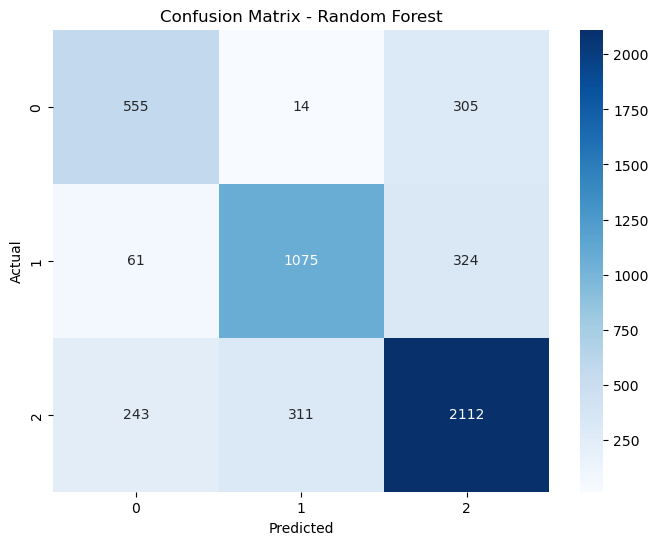

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Confusion Matrix Analysis

Berdasarkan confusion matrix, model Random Forest mampu mengklasifikasikan sebagian besar data dengan benar pada ketiga kelas Credit Score. Kelas Standard memiliki tingkat prediksi yang paling baik dengan jumlah prediksi benar tertinggi dibandingkan kelas lainnya.

Sebagian besar kesalahan klasifikasi terjadi antara kelas Good dan Standard serta antara kelas Poor dan Standard. Hal ini menunjukkan bahwa karakteristik pelanggan pada kategori Standard memiliki kemiripan dengan dua kategori lainnya sehingga lebih sulit dibedakan secara sempurna.

In [73]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.65      0.64      0.64       874
           1       0.77      0.74      0.75      1460
           2       0.77      0.79      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.73      0.72      0.72      5000
weighted avg       0.75      0.75      0.75      5000



### Classification Report Analysis

Hasil evaluasi menunjukkan bahwa model Random Forest menghasilkan weighted F1-Score sebesar 74.80% dengan accuracy sebesar 74.84%.

Kelas Standard memperoleh performa terbaik dengan F1-Score sebesar 78%, sedangkan kelas Good memiliki performa terendah dengan F1-Score sebesar 64%. Meskipun demikian, seluruh kelas berhasil diprediksi dengan tingkat performa yang cukup baik sehingga model dianggap mampu melakukan klasifikasi multiclass secara efektif.

In [74]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
15,Outstanding_Debt,0.096002
7,Interest_Rate,0.071872
10,Delay_from_due_date,0.058728
12,Changed_Credit_Limit,0.053930
14,Credit_Mix,0.052854
23,Debt_to_Income_Ratio,0.049275
22,Credit_History_Months,0.046952
6,Num_Credit_Card,0.041668
21,Monthly_Balance,0.040612
16,Credit_Utilization_Ratio,0.040414


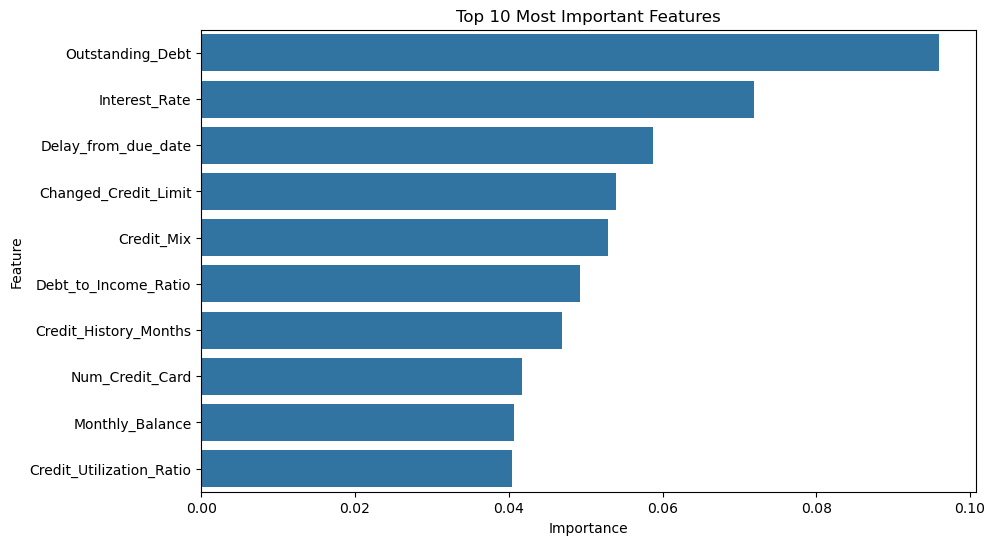

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Most Important Features'
)

plt.show()

### Feature Importance Analysis

Analisis feature importance menunjukkan bahwa Outstanding Debt merupakan faktor yang paling berpengaruh dalam menentukan Credit Score pelanggan, diikuti oleh Interest Rate, Delay from Due Date, Changed Credit Limit, dan Credit Mix.

Temuan ini sejalan dengan praktik penilaian kredit pada institusi keuangan, dimana jumlah hutang yang dimiliki pelanggan, tingkat bunga, riwayat keterlambatan pembayaran, serta kualitas kredit menjadi indikator utama dalam menilai risiko kredit pelanggan.

# Final Model Conclusion

Penelitian ini bertujuan untuk membangun model machine learning yang mampu memprediksi Credit Score pelanggan berdasarkan informasi finansial dan perilaku kredit pelanggan.

Setelah melalui proses data preprocessing, feature engineering, dan eksperimen terhadap lima algoritma machine learning, diperoleh bahwa Random Forest memberikan performa terbaik dengan Accuracy sebesar 74.84% dan F1-Score sebesar 74.80%.

Hasil evaluasi menunjukkan bahwa model berbasis tree secara konsisten menghasilkan performa yang lebih baik dibandingkan model linear. Selain itu, analisis feature importance menunjukkan bahwa Outstanding Debt, Interest Rate, Delay from Due Date, Credit Mix, dan Credit History merupakan faktor yang paling berpengaruh terhadap kualitas kredit pelanggan.

Berdasarkan hasil eksperimen tersebut, Random Forest dipilih sebagai model final yang akan digunakan pada tahap pipeline training, experiment tracking menggunakan MLflow, dan deployment berbasis web.

In [76]:
df["Credit_Score"].value_counts()

Credit_Score
2    13330
1     7302
0     4368
Name: count, dtype: int64